# Price Monitor — Complete data science workflow

This notebook combines the former exploratory notebook and modeling notebook into one reproducible workflow for Brent crude oil and gasoil benchmark prices.

## Problem Definition

**Goal.** Forecast the first published market price on or after **1, 7, 30, and 90 calendar days** for Brent (USD/barrel) and gasoil (USD/gallon).

**Business use.** Support monitoring, budgeting, and procurement planning with transparent benchmark forecasts. These are market indicators, not executable supplier quotes.

**Success criteria.**

- Compare every model with a persistence baseline using chronological validation.
- Prefer a more complex model only when it improves validation MAE by at least 2%.
- Keep the final 20% of history untouched until model selection is complete.
- Report MAE, RMSE, MAPE, directional accuracy, skill versus persistence, and interval coverage.

**Scope and constraints.** Bitumen is excluded because the repository does not contain a comparable daily transaction-price history. Historical release timestamps and revisions are unavailable, so this is a source-date experiment rather than a true point-in-time trading simulation.

In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve()
while not (ROOT / "price_monitor").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / "price_monitor").exists():
    raise RuntimeError("Run this notebook from the repository or its notebooks directory.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA = ROOT / "data" / "processed" / "market_prices.csv"
REPORTS = ROOT / "reports" / "data_science"
REPORTS.mkdir(parents=True, exist_ok=True)

from price_monitor.analysis.data import PRODUCTS, UNITS, audit_data, load_market_data
from price_monitor.analysis.features import make_features, make_supervised, purged_splits
from price_monitor.analysis.modeling import SEED, candidates
from price_monitor.analysis.pipeline import run_analysis

get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)
print("Repository:", ROOT.name)
print("Data:", DATA.relative_to(ROOT))

Repository: repo_push
Data: data\processed\market_prices.csv


## 1. Data Collection

The project stores a processed union of two FRED series and their bundled raw CSV snapshots:

- **DCOILBRENTEU** — Europe Brent spot price, USD/barrel.
- **DDFUELNYH** — New York Harbor ultra-low-sulfur diesel spot price, USD/gallon.

The workflow is offline and deterministic for a fixed snapshot. It records file hashes and verifies that processed values match the bundled raw files; this proves local consistency, not upstream authenticity.

In [2]:
frame = load_market_data(DATA)
audit = audit_data(frame, DATA)

source_summary = pd.DataFrame(audit["products"]).T.reset_index(names="product")
display(source_summary[[
    "product", "unit", "observations", "latest_source_date",
    "missing_in_union_index", "longest_gap_calendar_days", "raw_mismatches"
]])
print(f"Snapshot: {audit['start']} to {audit['end']} | {audit['rows']:,} rows")
print(f"SHA-256: {audit['sha256']}")
display(frame.head())

,product,unit,observations,latest_source_date,missing_in_union_index,longest_gap_calendar_days,raw_mismatches
0,brent,USD/barrel,1263,2026-09-09,24,5,0
1,gasoil,USD/gallon,1246,2026-09-09,41,5,0


Snapshot: 2021-09-10 to 2026-09-09 | 1,287 rows
SHA-256: 98aa047ab90dfec93ab188f50c79fd33b4b60188047560b6f132458ebb12aa26


,brent,gasoil
date,,
2021-09-10,72.44,2.140
2021-09-13,72.97,2.160
2021-09-14,73.05,2.161
2021-09-15,74.84,2.207
2021-09-16,75.14,2.214


## 2. Data Understanding / Exploration

Each row is a source date. The products publish on different schedules, so a missing value in the union index is not automatically a data-quality failure. We inspect schema, coverage, distributions, and publication gaps before transforming anything.

In [3]:
understanding = pd.DataFrame({
    "dtype": frame.dtypes.astype(str),
    "observations": frame.notna().sum(),
    "missing_rows": frame.isna().sum(),
    "missing_pct": frame.isna().mean().mul(100).round(2),
    "minimum": frame.min(),
    "median": frame.median(),
    "mean": frame.mean(),
    "maximum": frame.max(),
})
display(understanding)

publication_gaps = pd.DataFrame({
    product: frame[product].dropna().index.to_series().diff().dt.days.describe()
    for product in PRODUCTS
}).T
publication_gaps.index.name = "product"
display(publication_gaps)

,dtype,observations,missing_rows,missing_pct,minimum,median,mean,maximum
brent,float64,1263,24,1.86,59.930,81.6600,84.025131,138.210
gasoil,float64,1246,41,3.19,1.972,2.6235,2.902431,5.339


,count,mean,std,min,25%,50%,75%,max
product,,,,,,,,
brent,1262.0,1.446117,0.889553,1.0,1.0,1.0,1.0,5.0
gasoil,1245.0,1.465863,0.900964,1.0,1.0,1.0,1.0,5.0


## 3. Data Cleaning

`load_market_data` performs the cleaning contract: strict date parsing, chronological sorting, duplicate-date rejection, numeric coercion, and positive finite-price validation. Missing publication days are retained. We do **not** interpolate targets or forward-fill prices because that would create synthetic observations.

In [4]:
cleaning_checks = pd.Series({
    "duplicate_dates": int(frame.index.duplicated().sum()),
    "dates_sorted": bool(frame.index.is_monotonic_increasing),
    "future_dates": int((frame.index.date > pd.Timestamp.now(tz="UTC").date()).sum()),
    "non_positive_values": int(((frame <= 0) & frame.notna()).sum().sum()),
    "non_finite_values": int((~np.isfinite(frame.to_numpy()) & frame.notna().to_numpy()).sum()),
    "raw_processed_mismatches": int(sum(
        details.get("raw_mismatches", 0) for details in audit["products"].values()
    )),
}, name="result")
display(cleaning_checks.to_frame())

assert cleaning_checks["duplicate_dates"] == 0
assert cleaning_checks["dates_sorted"]
assert cleaning_checks["future_dates"] == 0
assert cleaning_checks["non_positive_values"] == 0
assert cleaning_checks["non_finite_values"] == 0
assert cleaning_checks["raw_processed_mismatches"] == 0

clean = frame.copy()
print("Cleaning checks passed. Missing publication days remain explicit.")

,result
duplicate_dates,0
dates_sorted,True
future_dates,0
non_positive_values,0
non_finite_values,0
raw_processed_mismatches,0


Cleaning checks passed. Missing publication days remain explicit.


## 4. Exploratory Data Analysis (EDA)

To reduce look-ahead bias, diagnostic decisions use only the first 65% of dates. Price levels provide business context; log returns are better suited to volatility, co-movement, seasonality, and anomaly screening.

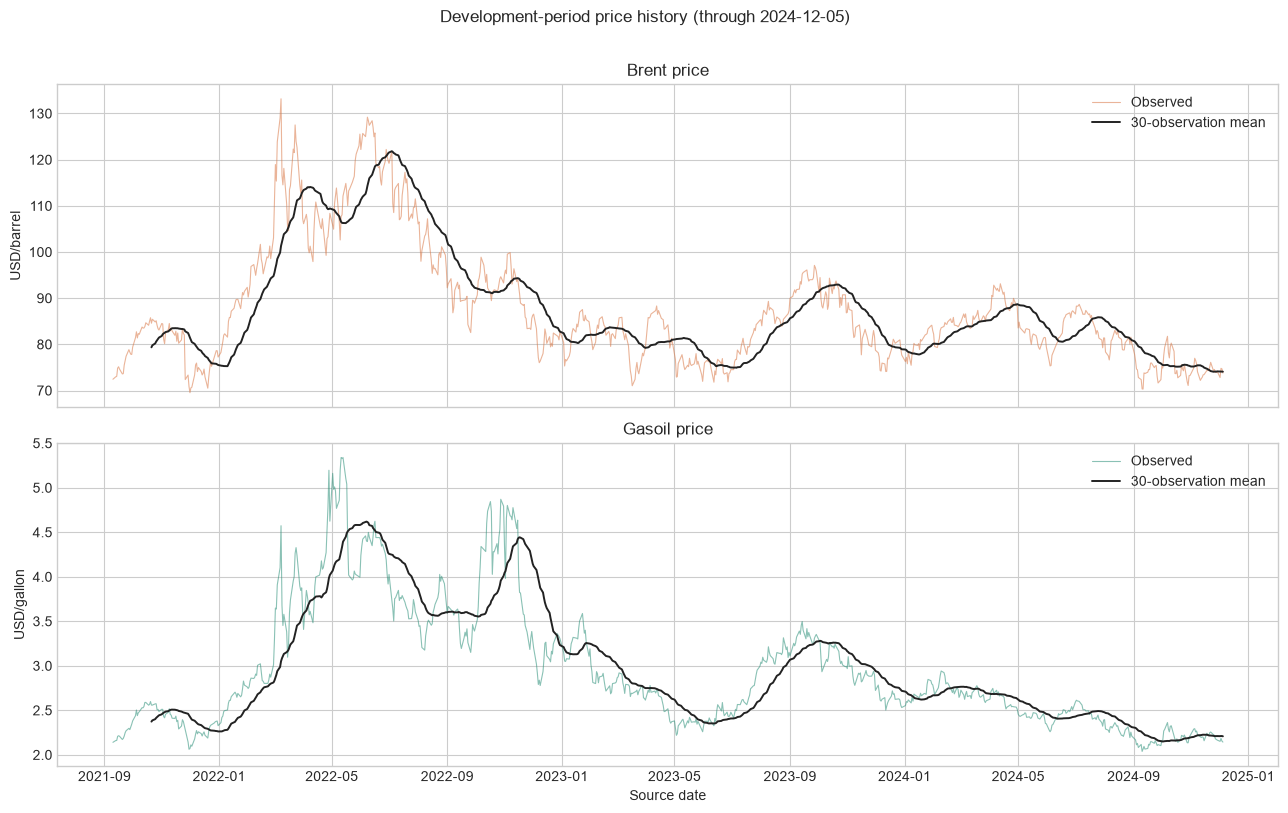

In [5]:
diagnostic_cutoff = clean.index[int(len(clean) * 0.65)]
diagnostic = clean.loc[clean.index < diagnostic_cutoff]

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
colors = {"brent": "#d97745", "gasoil": "#2a8f78"}
for ax, product in zip(axes, PRODUCTS):
    series = diagnostic[product].dropna()
    ax.plot(series.index, series, color=colors[product], alpha=0.55, lw=0.8, label="Observed")
    ax.plot(series.rolling(30).mean(), color="#222222", lw=1.4, label="30-observation mean")
    ax.set_title(f"{product.title()} price")
    ax.set_ylabel(UNITS[product])
    ax.legend()
axes[-1].set_xlabel("Source date")
fig.suptitle(f"Development-period price history (through {diagnostic.index.max().date()})", y=1.01)
plt.tight_layout()
plt.show()

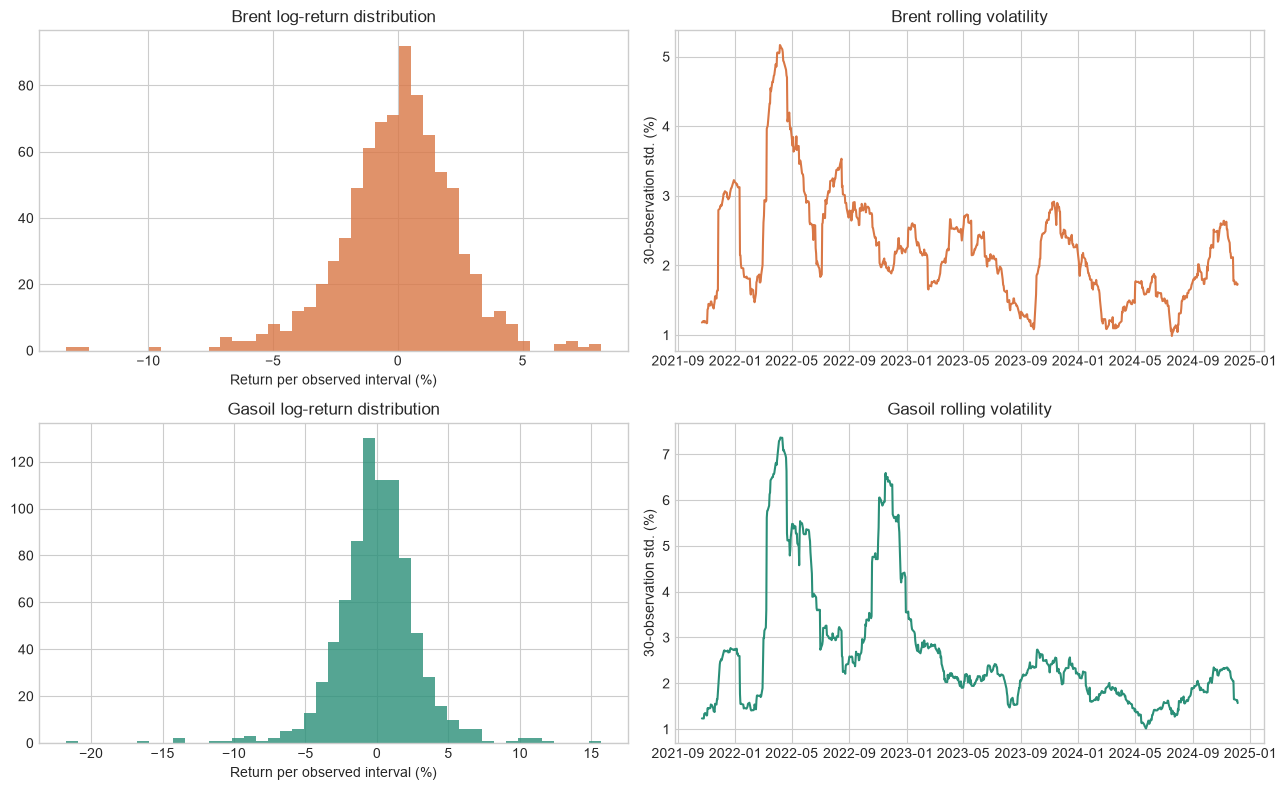

Aligned-return correlation: 0.558


In [6]:
log_returns = pd.DataFrame({
    product: np.log(diagnostic[product].dropna()).diff()
    for product in PRODUCTS
})

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for row, product in enumerate(PRODUCTS):
    returns_pct = log_returns[product].dropna().mul(100)
    axes[row, 0].hist(returns_pct, bins=45, color=colors[product], alpha=0.8)
    axes[row, 0].set_title(f"{product.title()} log-return distribution")
    axes[row, 0].set_xlabel("Return per observed interval (%)")
    axes[row, 1].plot(returns_pct.rolling(30).std(), color=colors[product])
    axes[row, 1].set_title(f"{product.title()} rolling volatility")
    axes[row, 1].set_ylabel("30-observation std. (%)")
plt.tight_layout()
plt.show()

paired_prices = diagnostic[["brent", "gasoil"]].dropna()
paired_returns = np.log(paired_prices).diff().dropna()
print(f"Aligned-return correlation: {paired_returns.corr().loc['brent', 'gasoil']:.3f}")

,product,date,log_return_pct,robust_z
17,gasoil,2022-03-09,-21.780032,-9.945534
28,gasoil,2022-10-19,-16.174883,-7.390046
31,gasoil,2022-11-03,15.705313,7.144710
4,brent,2022-03-09,-13.312386,-6.907281
0,brent,2021-11-26,-12.553697,-6.517839
32,gasoil,2022-11-16,-14.135977,-6.460471
25,gasoil,2022-05-18,-13.648359,-6.238158
21,gasoil,2022-04-04,12.090804,5.496790
23,gasoil,2022-04-29,-11.662897,-5.332950
9,brent,2022-07-05,-9.745534,-5.076385


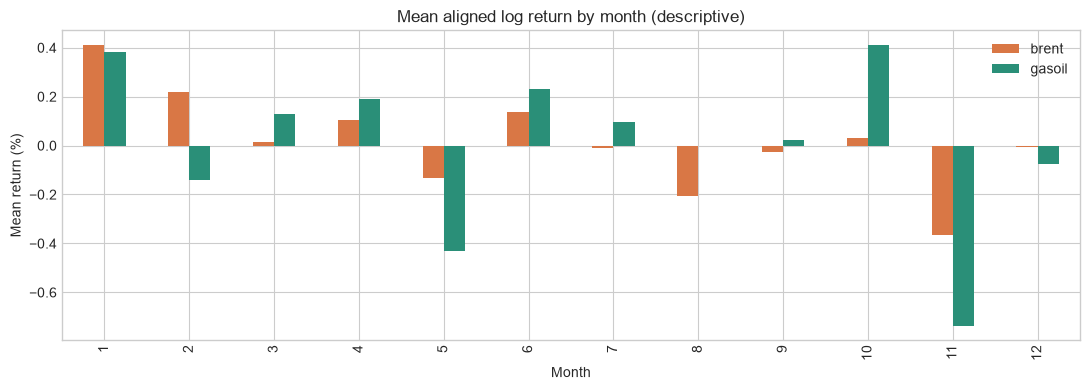

Robust shock flags: 33. They are documented, not automatically removed.


In [7]:
def robust_z_score(series):
    median = series.median()
    mad = (series - median).abs().median()
    return pd.Series(0.0, index=series.index) if not mad else 0.6745 * (series - median) / mad

shock_rows = []
for product in PRODUCTS:
    returns = log_returns[product].dropna()
    scores = robust_z_score(returns)
    flagged = scores[scores.abs() > 3.5]
    shock_rows.extend({
        "product": product,
        "date": date,
        "log_return_pct": returns.loc[date] * 100,
        "robust_z": score,
    } for date, score in flagged.items())

shocks = pd.DataFrame(shock_rows)
if not shocks.empty:
    shocks["absolute_z"] = shocks["robust_z"].abs()
    display(shocks.nlargest(12, "absolute_z").drop(columns="absolute_z"))

monthly_returns = paired_returns.groupby(paired_returns.index.month).mean().mul(100)
ax = monthly_returns.plot.bar(figsize=(11, 4), color=[colors["brent"], colors["gasoil"]])
ax.set(title="Mean aligned log return by month (descriptive)", xlabel="Month", ylabel="Mean return (%)")
plt.tight_layout()
plt.show()
print(f"Robust shock flags: {len(shocks)}. They are documented, not automatically removed.")

### Additional EDA graphs selected for these variables

The earlier cells already provide the required **time-series plots** and **histograms**. The figures below add the most useful remaining raw-data views:

- an observation-count and missing-values plot for publication coverage;
- a box plot for comparing return distributions and outliers;
- a scatter plot for aligned Brent–gasoil co-movement.

A count plot for categorical records is not appropriate because the source table contains continuous prices indexed by time. Observation counts by product provide the relevant equivalent.

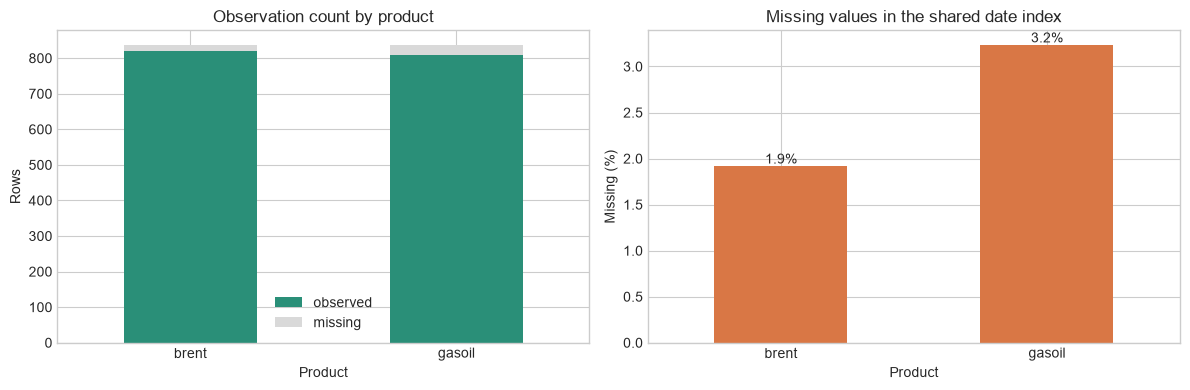

,observed,missing,missing_pct
brent,820,16,1.913876
gasoil,809,27,3.229665


In [8]:
coverage = pd.DataFrame({
    "observed": diagnostic.notna().sum(),
    "missing": diagnostic.isna().sum(),
})
coverage["missing_pct"] = diagnostic.isna().mean().mul(100)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
coverage[["observed", "missing"]].plot.bar(
    stacked=True, ax=axes[0], color=["#2a8f78", "#d9d9d9"]
)
axes[0].set(title="Observation count by product", xlabel="Product", ylabel="Rows")
axes[0].tick_params(axis="x", rotation=0)

coverage["missing_pct"].plot.bar(ax=axes[1], color="#d97745")
axes[1].set(title="Missing values in the shared date index", xlabel="Product", ylabel="Missing (%)")
axes[1].tick_params(axis="x", rotation=0)
for position, value in enumerate(coverage["missing_pct"]):
    axes[1].text(position, value, f"{value:.1f}%", ha="center", va="bottom")
plt.tight_layout()
plt.show()
display(coverage)

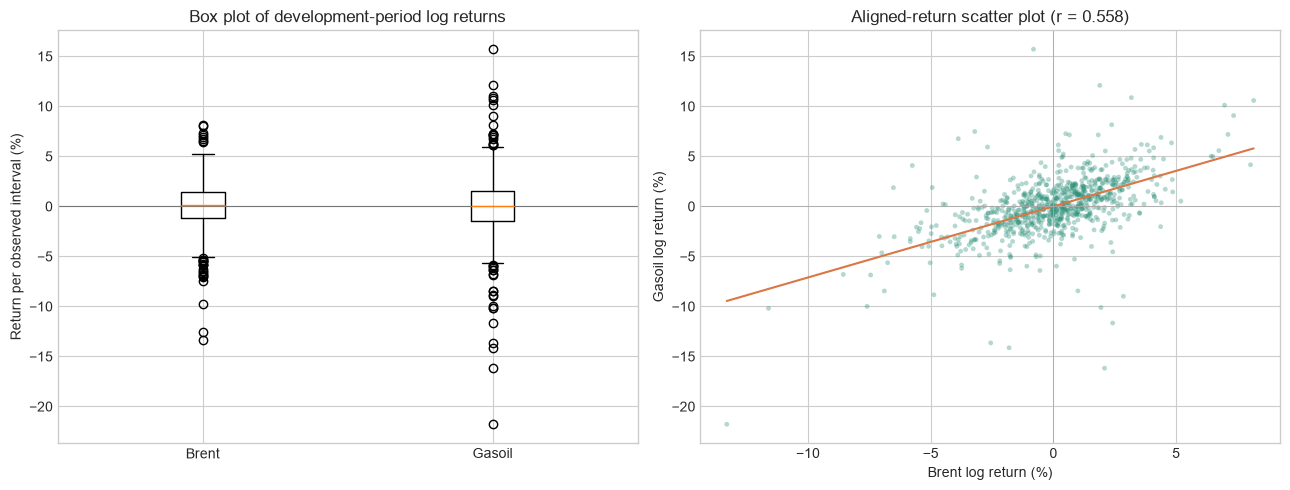

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

return_values = [log_returns[product].dropna().mul(100) for product in PRODUCTS]
axes[0].boxplot(return_values, tick_labels=[product.title() for product in PRODUCTS], showfliers=True)
axes[0].axhline(0, color="#777", lw=0.8)
axes[0].set(title="Box plot of development-period log returns", ylabel="Return per observed interval (%)")

x = paired_returns["brent"].mul(100)
y = paired_returns["gasoil"].mul(100)
axes[1].scatter(x, y, s=12, alpha=0.35, color="#2a8f78", edgecolors="none")
if len(x) > 1:
    slope, intercept = np.polyfit(x, y, 1)
    line_x = np.linspace(x.min(), x.max(), 100)
    axes[1].plot(line_x, slope * line_x + intercept, color="#d97745", lw=1.5)
axes[1].axhline(0, color="#aaa", lw=0.6)
axes[1].axvline(0, color="#aaa", lw=0.6)
axes[1].set(
    title=f"Aligned-return scatter plot (r = {x.corr(y):.3f})",
    xlabel="Brent log return (%)",
    ylabel="Gasoil log return (%)",
)
plt.tight_layout()
plt.show()

## 5. Feature Engineering

Features are causal at forecast origin *t*: lagged log returns, rolling price ratios, momentum, volatility, publication-gap length, cyclical calendar terms, and strictly earlier observations of the other product. Cross-product observations older than seven days remain missing and are imputed inside each training fold.

The target is a log return from the current observed price to the first actual publication on or after the requested calendar horizon, allowing at most four days of publication delay.

In [10]:
example_product = "brent"
example_horizon = 30
engineered = make_features(clean, example_product)
supervised_x, labels = make_supervised(clean, example_product, example_horizon)

feature_groups = pd.Series({
    "lagged_returns": len([c for c in engineered if c.startswith("log_return_")]),
    "rolling_price_ratios": len([c for c in engineered if c.startswith("price_to_mean_")]),
    "momentum": len([c for c in engineered if c.startswith("momentum_")]),
    "volatility": len([c for c in engineered if c.startswith("volatility_")]),
    "calendar_cycles": len([c for c in engineered if c.endswith(("_sin", "_cos"))]),
    "peer_market": len([c for c in engineered if c.startswith("peer_") or c.startswith("relative_")]),
    "publication_gap": int("gap_days" in engineered),
}, name="feature_count")
display(feature_groups.to_frame())
display(pd.concat([supervised_x.tail(3), labels.tail(3)], axis=1))
print(f"{supervised_x.shape[1]} features | {len(labels):,} labeled origins for {example_horizon} calendar days")

,feature_count
lagged_returns,6
rolling_price_ratios,3
momentum,3
volatility,3
calendar_cycles,6
peer_market,5
publication_gap,1


,log_price,log_return_1,log_return_2,log_return_5,log_return_10,log_return_20,log_return_60,price_to_mean_5,volatility_5,momentum_5,price_to_mean_20,volatility_20,momentum_20,price_to_mean_60,volatility_60,momentum_60,gap_days,weekday_sin,weekday_cos,month_sin,month_cos,day_of_year_sin,day_of_year_cos,peer_log_price,peer_log_return_1,peer_log_return_5,peer_age_days,relative_momentum_5,target_date,current_price,target_price,target_log_return,target_delay_days
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-08-06,4.495913,0.034036,0.036116,-0.024897,-0.161090,0.185651,-0.207109,-0.000825,0.055161,-0.004979,0.007660,0.057142,0.009283,0.010517,0.041966,-0.003452,1.0,0.433884,-0.900969,-0.5,-0.866025,-0.557468,-0.830198,1.339989,0.016368,-0.147282,1.0,0.122385,2026-09-07,89.65,104.47,0.152987,2
2026-08-07,4.473009,-0.022904,0.011132,-0.101186,-0.135256,0.164360,-0.235710,-0.002709,0.044502,-0.020237,-0.022453,0.057552,0.008218,-0.008025,0.042023,-0.003928,1.0,-0.433884,-0.900969,-0.5,-0.866025,-0.571667,-0.820486,1.377506,0.037517,-0.065877,1.0,-0.035309,2026-09-07,87.62,104.47,0.175891,1
2026-08-10,4.529800,0.056791,0.033887,0.042288,0.009970,0.127726,-0.206048,0.046420,0.036479,0.008458,0.028291,0.055234,0.006386,0.054161,0.042566,-0.003434,3.0,0.000000,1.000000,-0.5,-0.866025,-0.613230,-0.789905,1.363537,-0.013968,-0.062218,3.0,0.104506,2026-09-09,92.74,109.51,0.166216,0


28 features | 1,182 labeled origins for 30 calendar days


### Feature design and formulas

The engineered variables capture level, trend, risk, calendar behavior, and cross-market context:

| Feature family | Construction | Purpose |
|---|---|---|
| Current level | `log(price_t)` | Stabilizes scale and preserves the information known at the forecast origin. |
| Lagged returns | `log(price_t / price_t-k)` for 1, 2, 5, 10, 20, and 60 observations | Measures short- and medium-term price change. |
| Relative level | `price_t / rolling_mean_w - 1` for 5, 20, and 60 observations | Shows whether price is above or below its recent regime. |
| Momentum | Rolling mean of one-observation log returns | Summarizes recent direction. |
| Volatility | Rolling standard deviation of one-observation log returns | Measures recent uncertainty. |
| Publication gap | Calendar days since the product's previous observation | Captures irregular market-publication spacing. |
| Calendar cycles | Sine/cosine encodings of weekday, month, and day of year | Represents cyclic time effects without artificial end-point jumps. |
| Peer market | Strictly earlier price and return features from the other product | Adds cross-market context while blocking same-date leakage. |
| Relative momentum | Product five-observation return minus peer return | Measures divergence between Brent and gasoil. |

Rolling windows count actual observations rather than calendar days. A genuine 60-observation warm-up is required, and missing peer features are left for fold-specific imputation.

,product,rows_after_warmup,feature_count,first_feature_date,last_feature_date,missing_cells,missing_pct
0,brent,1203,28,2021-12-03,2026-09-09,0,0.0
1,gasoil,1186,28,2021-12-07,2026-09-09,0,0.0


,brent,gasoil
feature,,
log_price,0.0,0.0
log_return_1,0.0,0.0
log_return_2,0.0,0.0
log_return_5,0.0,0.0
log_return_10,0.0,0.0
log_return_20,0.0,0.0
log_return_60,0.0,0.0
price_to_mean_5,0.0,0.0
volatility_5,0.0,0.0


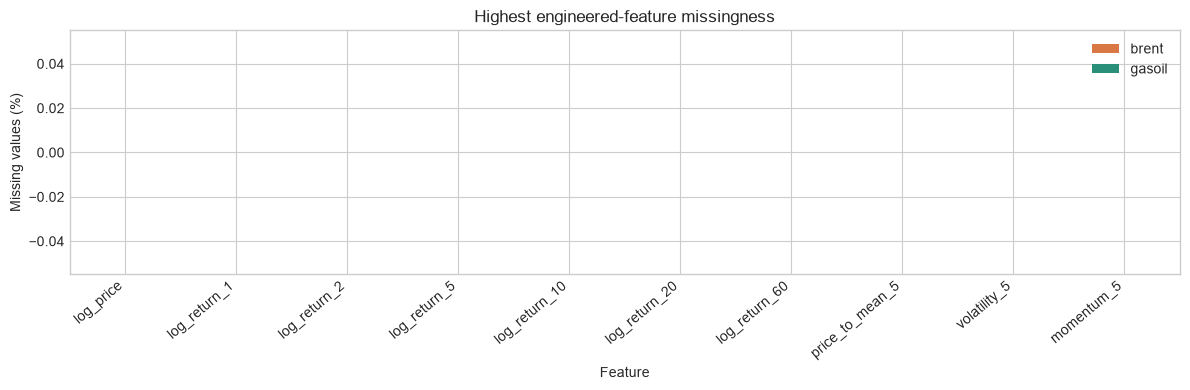

In [11]:
feature_diagnostics = []
feature_sets = {}

for product in PRODUCTS:
    product_features = make_features(clean, product)
    feature_sets[product] = product_features
    feature_diagnostics.append({
        "product": product,
        "rows_after_warmup": len(product_features),
        "feature_count": product_features.shape[1],
        "first_feature_date": product_features.index.min(),
        "last_feature_date": product_features.index.max(),
        "missing_cells": int(product_features.isna().sum().sum()),
        "missing_pct": product_features.isna().mean().mean() * 100,
    })

display(pd.DataFrame(feature_diagnostics))

missingness = pd.DataFrame({
    product: features.isna().mean().mul(100)
    for product, features in feature_sets.items()
}).sort_values("brent", ascending=False)
display(missingness.head(10).round(2).rename_axis("feature"))

ax = missingness.head(10).plot.bar(figsize=(12, 4), color=["#d97745", "#2a8f78"])
ax.set(title="Highest engineered-feature missingness", xlabel="Feature", ylabel="Missing values (%)")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

### Feature relevance and leakage controls

Correlation is shown only as a descriptive screening aid; it is not used to remove variables or claim causality. The calculation below uses origins whose targets finish before the EDA cutoff, so later calibration and holdout outcomes remain unseen.

,correlation_with_target
log_price,-0.347708
peer_log_price,-0.239522
month_cos,0.206714
day_of_year_cos,0.174994
day_of_year_sin,0.168043
price_to_mean_60,-0.125658
month_sin,0.121235
volatility_5,-0.114767
momentum_60,-0.111863
log_return_60,-0.111863


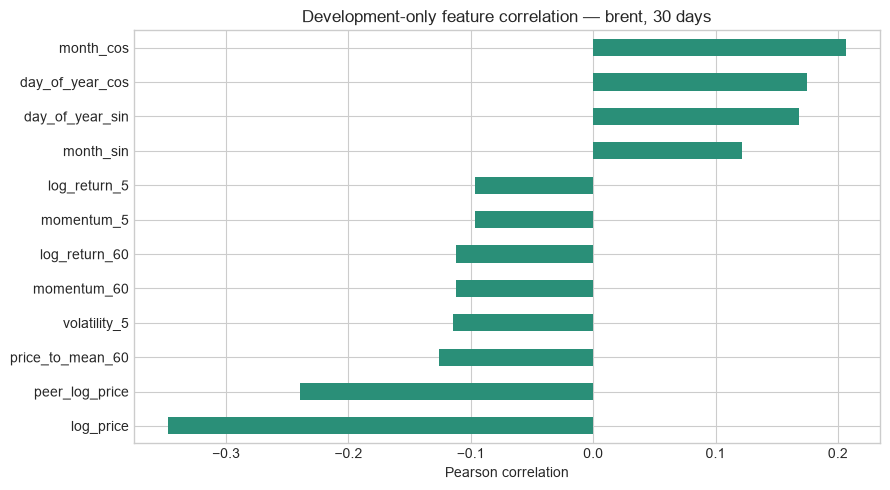

,result
target_columns_in_features,False
targets_strictly_after_origins,True
peer_features_use_earlier_dates,True
target_prices_missing,0


In [12]:
safe_origins = labels.index[labels.target_date < diagnostic_cutoff]
feature_target = supervised_x.loc[safe_origins].copy()
feature_target["target_log_return"] = labels.loc[safe_origins, "target_log_return"]

target_correlation = (
    feature_target.corr(numeric_only=True)["target_log_return"]
    .drop("target_log_return")
    .dropna()
    .sort_values(key=lambda values: values.abs(), ascending=False)
    .head(12)
)
display(target_correlation.rename("correlation_with_target").to_frame())

ax = target_correlation.sort_values().plot.barh(figsize=(9, 5), color="#2a8f78")
ax.set(title=f"Development-only feature correlation — {example_product}, {example_horizon} days", xlabel="Pearson correlation")
plt.tight_layout()
plt.show()

leakage_checks = pd.Series({
    "target_columns_in_features": bool(set(labels.columns) & set(supervised_x.columns)),
    "targets_strictly_after_origins": bool((labels.target_date > labels.index).all()),
    "peer_features_use_earlier_dates": bool((engineered.peer_age_days.dropna() >= 1).all()),
    "target_prices_missing": int(labels.target_price.isna().sum()),
}, name="result")
display(leakage_checks.to_frame())

assert not leakage_checks["target_columns_in_features"]
assert leakage_checks["targets_strictly_after_origins"]
assert leakage_checks["peer_features_use_earlier_dates"]
assert leakage_checks["target_prices_missing"] == 0

### Multivariate feature and target graphs

These plots use only development-safe rows (`target_date < diagnostic_cutoff`):

- a correlation heatmap for selected engineered variables and the target;
- a compact pair plot for joint distributions and nonlinear patterns;
- a feature-vs-target scatter plot for the strongest descriptive correlation;
- a box plot of the target across recent-volatility quartiles.

The relationships are descriptive. They do not establish causality and do not use calibration or holdout outcomes for feature selection.

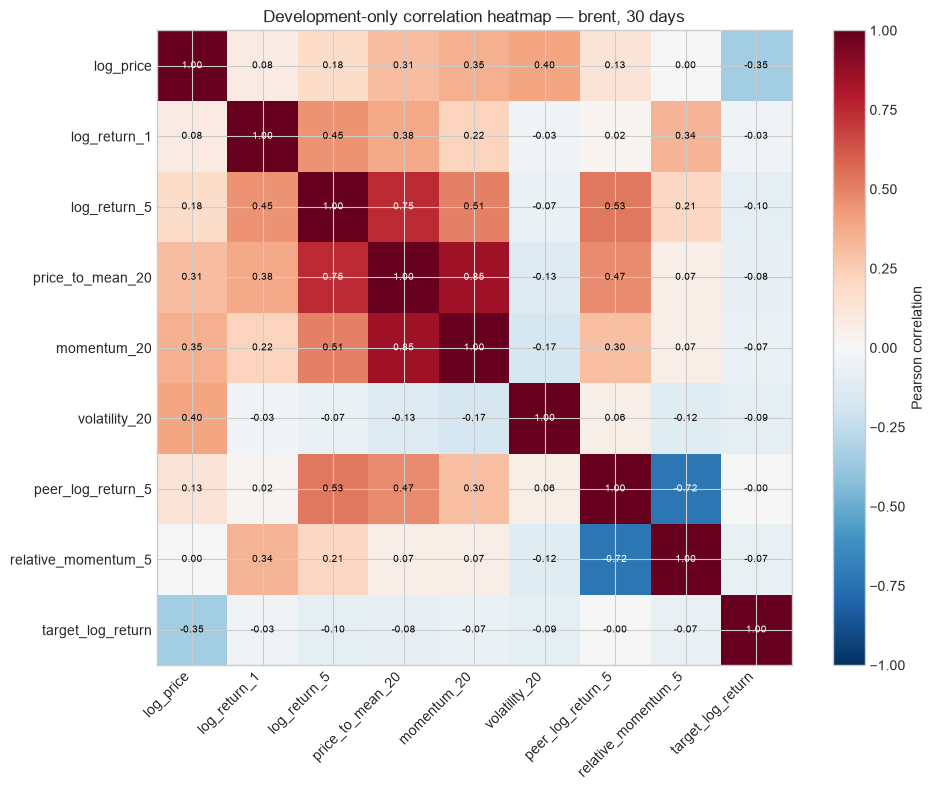

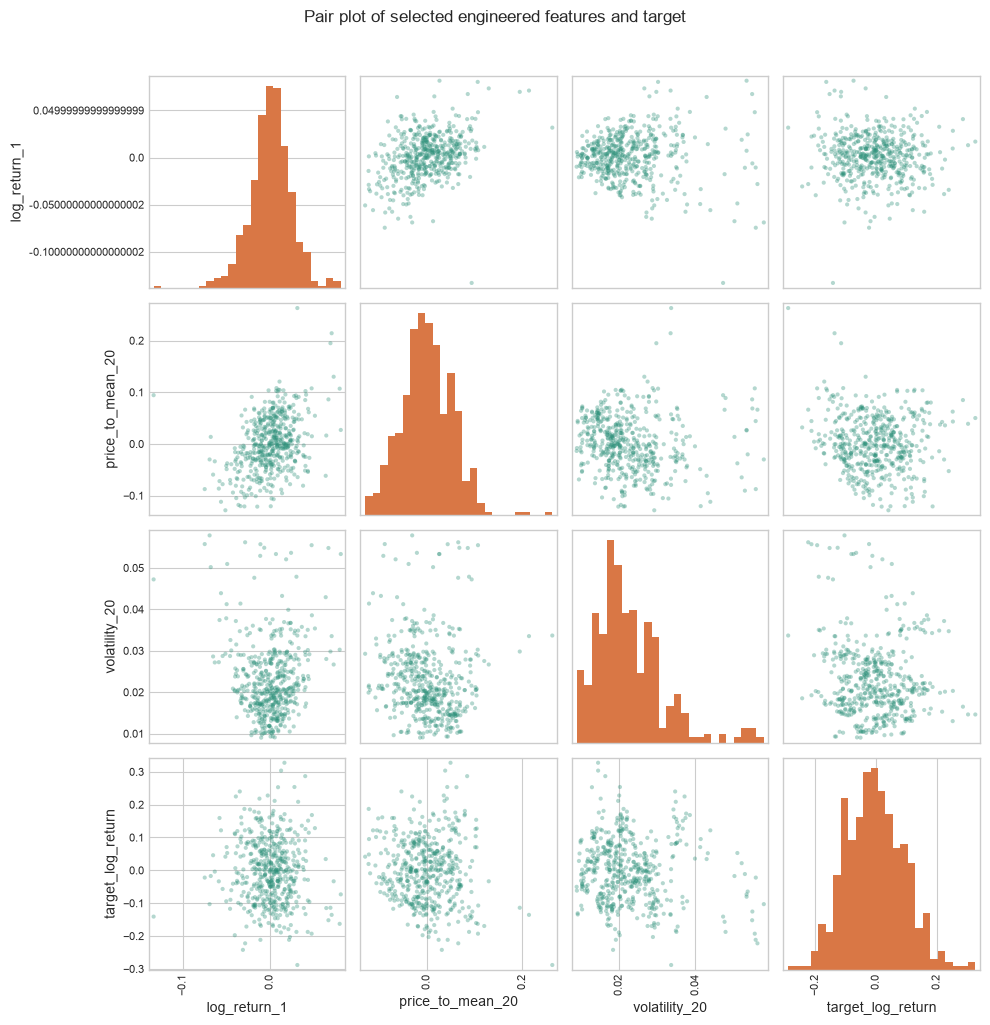

In [13]:
heatmap_columns = [
    "log_price", "log_return_1", "log_return_5", "price_to_mean_20",
    "momentum_20", "volatility_20", "peer_log_return_5",
    "relative_momentum_5", "target_log_return",
]
heatmap_columns = [column for column in heatmap_columns if column in feature_target.columns]
correlation_matrix = feature_target[heatmap_columns].corr()

fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(correlation_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(heatmap_columns)), heatmap_columns, rotation=45, ha="right")
ax.set_yticks(range(len(heatmap_columns)), heatmap_columns)
for row in range(len(heatmap_columns)):
    for column in range(len(heatmap_columns)):
        value = correlation_matrix.iloc[row, column]
        ax.text(column, row, f"{value:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(value) > 0.55 else "black")
fig.colorbar(image, ax=ax, label="Pearson correlation")
ax.set_title(f"Development-only correlation heatmap — {example_product}, {example_horizon} days")
plt.tight_layout()
plt.show()

pair_columns = ["log_return_1", "price_to_mean_20", "volatility_20", "target_log_return"]
pair_sample = feature_target[pair_columns].dropna()
if len(pair_sample) > 500:
    pair_sample = pair_sample.sample(500, random_state=SEED)
axes = pd.plotting.scatter_matrix(
    pair_sample, figsize=(10, 10), diagonal="hist", alpha=0.35,
    color="#2a8f78", hist_kwds={"bins": 25, "color": "#d97745"},
)
plt.suptitle("Pair plot of selected engineered features and target", y=1.02)
plt.tight_layout()
plt.show()

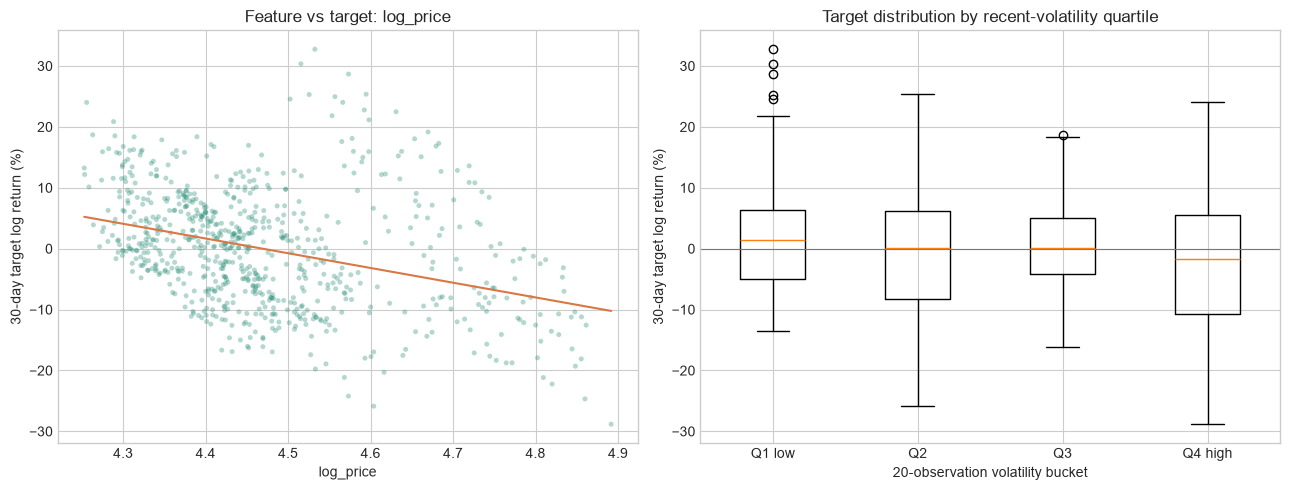

In [14]:
top_feature = target_correlation.index[0]
feature_vs_target = feature_target[[top_feature, "target_log_return"]].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(
    feature_vs_target[top_feature], feature_vs_target["target_log_return"].mul(100),
    s=13, alpha=0.35, color="#2a8f78", edgecolors="none",
)
if len(feature_vs_target) > 1:
    slope, intercept = np.polyfit(
        feature_vs_target[top_feature], feature_vs_target["target_log_return"].mul(100), 1
    )
    line_x = np.linspace(feature_vs_target[top_feature].min(), feature_vs_target[top_feature].max(), 100)
    axes[0].plot(line_x, slope * line_x + intercept, color="#d97745", lw=1.5)
axes[0].set(
    title=f"Feature vs target: {top_feature}",
    xlabel=top_feature,
    ylabel=f"{example_horizon}-day target log return (%)",
)

volatility_target = feature_target[["volatility_20", "target_log_return"]].dropna().copy()
volatility_target["volatility_quartile"] = pd.qcut(
    volatility_target["volatility_20"], q=4,
    labels=["Q1 low", "Q2", "Q3", "Q4 high"], duplicates="drop",
)
groups = [
    group["target_log_return"].mul(100).to_numpy()
    for _, group in volatility_target.groupby("volatility_quartile", observed=True)
]
labels_for_groups = [
    str(label) for label in volatility_target["volatility_quartile"].cat.categories
]
axes[1].boxplot(groups, tick_labels=labels_for_groups, showfliers=True)
axes[1].axhline(0, color="#777", lw=0.8)
axes[1].set(
    title="Target distribution by recent-volatility quartile",
    xlabel="20-observation volatility bucket",
    ylabel=f"{example_horizon}-day target log return (%)",
)
plt.tight_layout()
plt.show()

## 6. Data Preparation

The data is split chronologically using shared calendar boundaries:

- First 65%: development and expanding-window cross-validation.
- Next 15%: interval calibration.
- Final 20%: frozen holdout.

Training labels whose target dates cross into a validation period are purged. Imputation and scaling are fitted only inside each training pipeline.

In [15]:
calibration_start = clean.index[int(len(clean) * 0.65)]
holdout_start = clean.index[int(len(clean) * 0.80)]

development_idx = labels.index[labels.target_date < calibration_start]
calibration_idx = labels.index[
    (labels.index >= calibration_start) & (labels.target_date < holdout_start)
]
holdout_idx = labels.index[labels.index >= holdout_start]

split_summary = pd.DataFrame([
    {"split": "development", "rows": len(development_idx), "origin_start": development_idx.min(), "origin_end": development_idx.max()},
    {"split": "calibration", "rows": len(calibration_idx), "origin_start": calibration_idx.min(), "origin_end": calibration_idx.max()},
    {"split": "holdout", "rows": len(holdout_idx), "origin_start": holdout_idx.min(), "origin_end": holdout_idx.max()},
])
display(split_summary)

fold_rows = []
development_labels = labels.loc[development_idx]
for fold, (train_pos, valid_pos) in enumerate(purged_splits(development_labels), 1):
    train_idx = development_idx[train_pos]
    valid_idx = development_idx[valid_pos]
    fold_rows.append({
        "fold": fold,
        "train_rows": len(train_idx),
        "last_train_target": labels.loc[train_idx, "target_date"].max(),
        "validation_start": valid_idx.min(),
        "validation_end": valid_idx.max(),
        "leakage_check": labels.loc[train_idx, "target_date"].max() < valid_idx.min(),
    })
display(pd.DataFrame(fold_rows))

,split,rows,origin_start,origin_end
0,development,738,2021-12-03,2024-11-05
1,calibration,169,2024-12-06,2025-08-08
2,holdout,233,2025-09-09,2026-08-10


,fold,train_rows,last_train_target,validation_start,validation_end,leakage_check
0,1,165,2022-08-30,2022-08-31,2023-05-25,True
1,2,350,2023-05-25,2023-05-26,2024-02-14,True
2,3,532,2024-02-14,2024-02-15,2024-11-05,True


## 7. Model Selection

Candidate models balance strong baselines with interpretable and nonlinear alternatives. Selection uses mean purged cross-validation MAE. Persistence remains selected unless the best alternative improves MAE by at least 2%, which discourages unnecessary complexity.

In [16]:
model_catalog = pd.DataFrame([
    ("naive", "Baseline", "Last observed price (persistence)"),
    ("holt", "Statistical", "Corrected damped Holt trend"),
    ("ridge_1 / ridge_10 / ridge_100", "Linear ML", "Regularized log-return regression"),
    ("boosting_7 / boosting_15", "Tree ML", "Histogram gradient boosting"),
    ("random_forest", "Tree ML", "Random forest reference model"),
], columns=["candidate", "family", "role"])
display(model_catalog)
print("Implemented candidates:", ", ".join(candidates().keys()))
print("Selection rule: lowest mean purged-CV MAE, with >=2% improvement required over persistence.")

,candidate,family,role
0,naive,Baseline,Last observed price (persistence)
1,holt,Statistical,Corrected damped Holt trend
2,ridge_1 / ridge_10 / ridge_100,Linear ML,Regularized log-return regression
3,boosting_7 / boosting_15,Tree ML,Histogram gradient boosting
4,random_forest,Tree ML,Random forest reference model


Implemented candidates: naive, holt, ridge_1, ridge_10, ridge_100, boosting_7, boosting_15, random_forest
Selection rule: lowest mean purged-CV MAE, with >=2% improvement required over persistence.


## 8. Model Training

The reproducible pipeline trains every candidate for both products and all four horizons. It generates split audits, cross-validation scores, calibrated prediction intervals, feature importance, model cards, holdout predictions, figures, and an environment manifest.

In [17]:
manifest = run_analysis(
    DATA,
    REPORTS,
    horizons=(1, 7, 30, 90),
    save_models=False,
)

training_summary = pd.DataFrame(manifest["experiments"])[[
    "product", "horizon_days", "selected_model",
    "development_rows", "calibration_rows", "holdout_rows",
    "last_training_target",
]]
display(training_summary)

Evaluating brent, 1 calendar day(s)...


Evaluating brent, 7 calendar day(s)...


Evaluating brent, 30 calendar day(s)...


Evaluating brent, 90 calendar day(s)...


Evaluating gasoil, 1 calendar day(s)...


Evaluating gasoil, 7 calendar day(s)...


Evaluating gasoil, 30 calendar day(s)...


Evaluating gasoil, 90 calendar day(s)...


,product,horizon_days,selected_model,development_rows,calibration_rows,holdout_rows,last_training_target
0,brent,1,naive,759,188,253,2024-12-05
1,brent,7,naive,755,184,249,2024-12-05
2,brent,30,naive,738,169,233,2024-12-05
3,brent,90,naive,696,126,191,2024-12-05
4,gasoil,1,naive,748,186,249,2024-12-05
5,gasoil,7,naive,744,182,246,2024-12-04
6,gasoil,30,naive,729,167,229,2024-12-05
7,gasoil,90,naive,688,126,189,2024-12-05


## 9. Model Evaluation

The final holdout is scored only after validation-based selection. MAE and RMSE remain in each product's native unit and must not be averaged across products. Positive `mae_skill_vs_naive` means improvement over persistence. Interval coverage is measured empirically because time-series dependence prevents a distribution-free guarantee.

,product,horizon_days,model,samples,mae,rmse,mape_pct,direction_accuracy,mae_skill_vs_naive,interval_coverage,mean_interval_width
0,brent,1,naive,253,2.367747,3.655905,2.605782,0.003953,0.0,0.790514,6.602863
8,brent,7,naive,249,5.436185,7.710908,5.968934,0.000000,0.0,0.871486,20.794210
16,brent,30,naive,233,12.400858,17.824986,13.462639,0.000000,0.0,0.660944,24.695131
24,brent,90,naive,191,23.841832,30.648966,25.045822,0.000000,0.0,0.523560,33.379507
32,gasoil,1,naive,249,0.086614,0.125200,2.501707,0.000000,0.0,0.855422,0.297168
40,gasoil,7,naive,246,0.186175,0.254845,5.397346,0.004065,0.0,0.861789,0.682201
48,gasoil,30,naive,229,0.458672,0.630951,13.064640,0.000000,0.0,0.729258,1.018942
56,gasoil,90,naive,189,0.779873,1.045913,20.684905,0.000000,0.0,0.566138,1.272194


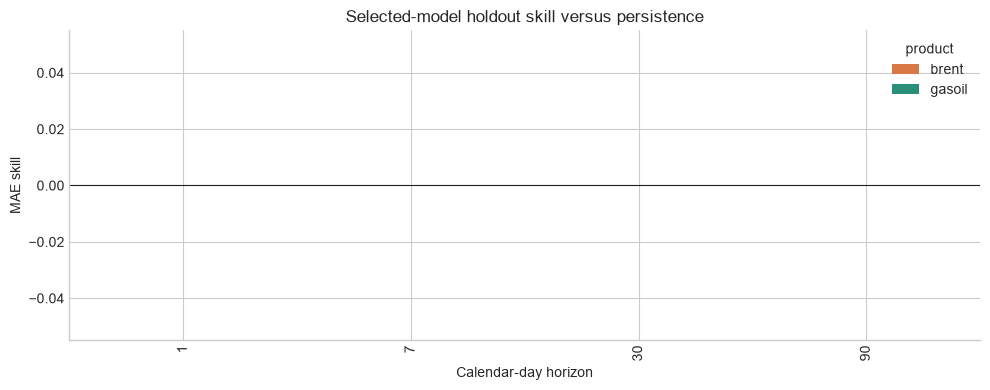

In [18]:
holdout_metrics = pd.read_csv(REPORTS / "holdout_metrics.csv")
validation_metrics = pd.read_csv(REPORTS / "cross_validation.csv")
selected = holdout_metrics[holdout_metrics.selected_on_validation].copy()

evaluation_columns = [
    "product", "horizon_days", "model", "samples", "mae", "rmse",
    "mape_pct", "direction_accuracy", "mae_skill_vs_naive",
    "interval_coverage", "mean_interval_width",
]
display(selected[evaluation_columns].sort_values(["product", "horizon_days"]))

skill = selected.pivot(index="horizon_days", columns="product", values="mae_skill_vs_naive")
ax = skill.plot.bar(figsize=(10, 4), color=["#d97745", "#2a8f78"])
ax.axhline(0, color="#222", lw=0.8)
ax.set(title="Selected-model holdout skill versus persistence", xlabel="Calendar-day horizon", ylabel="MAE skill")
plt.tight_layout()
plt.show()

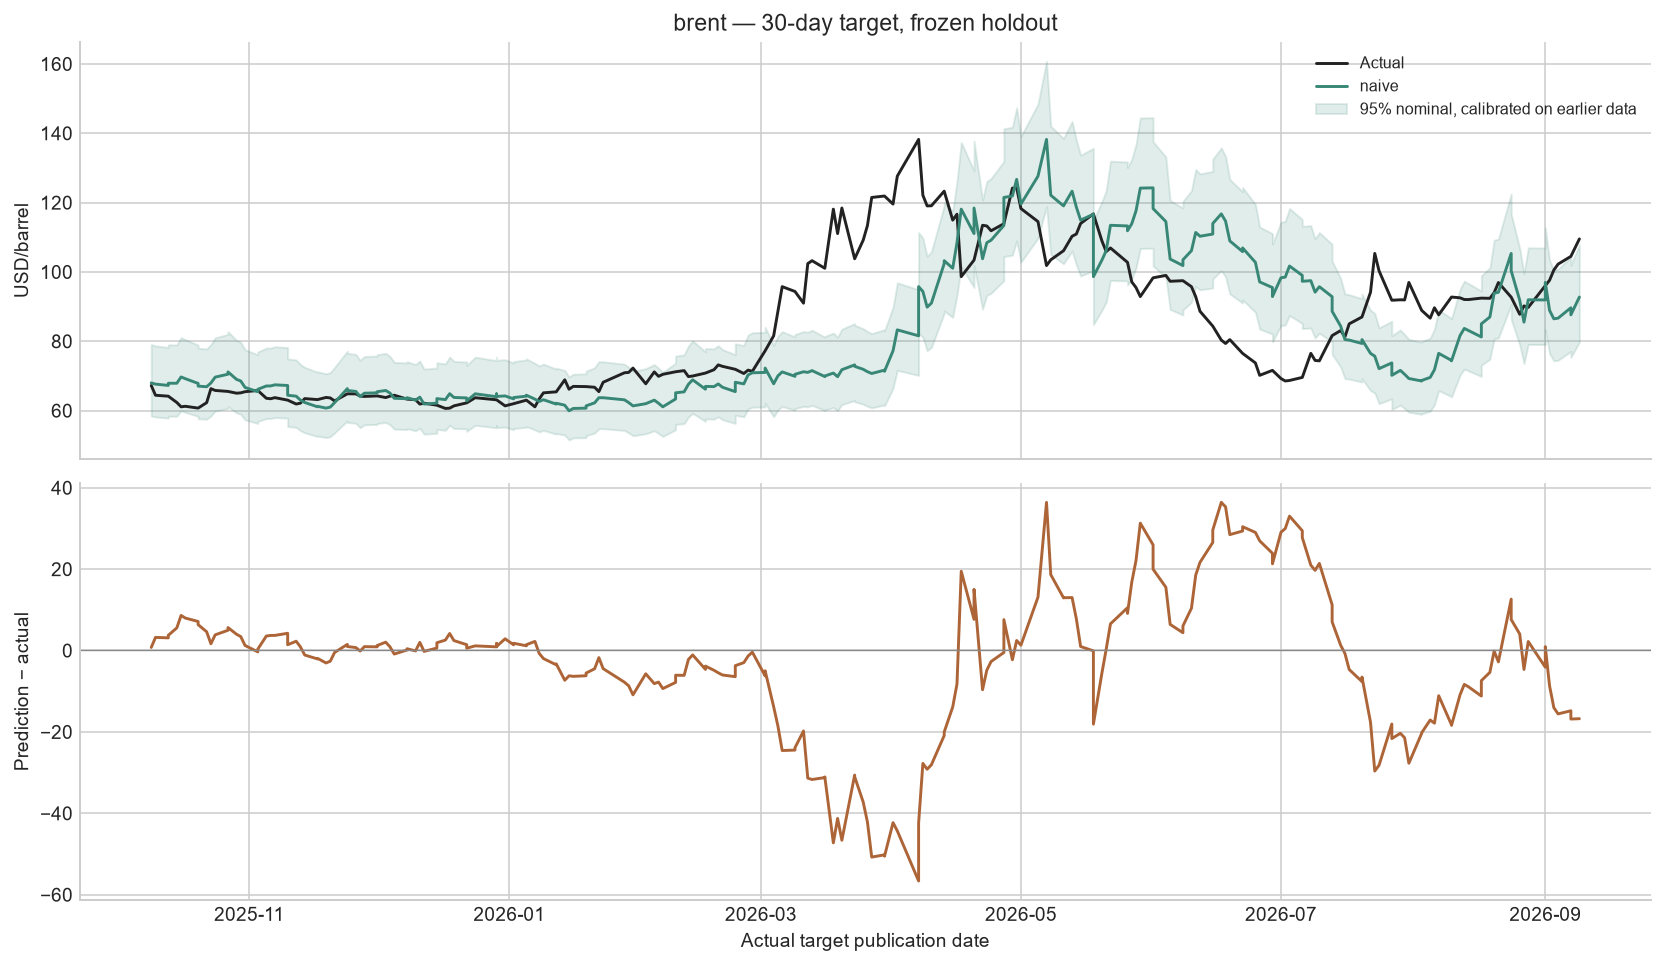

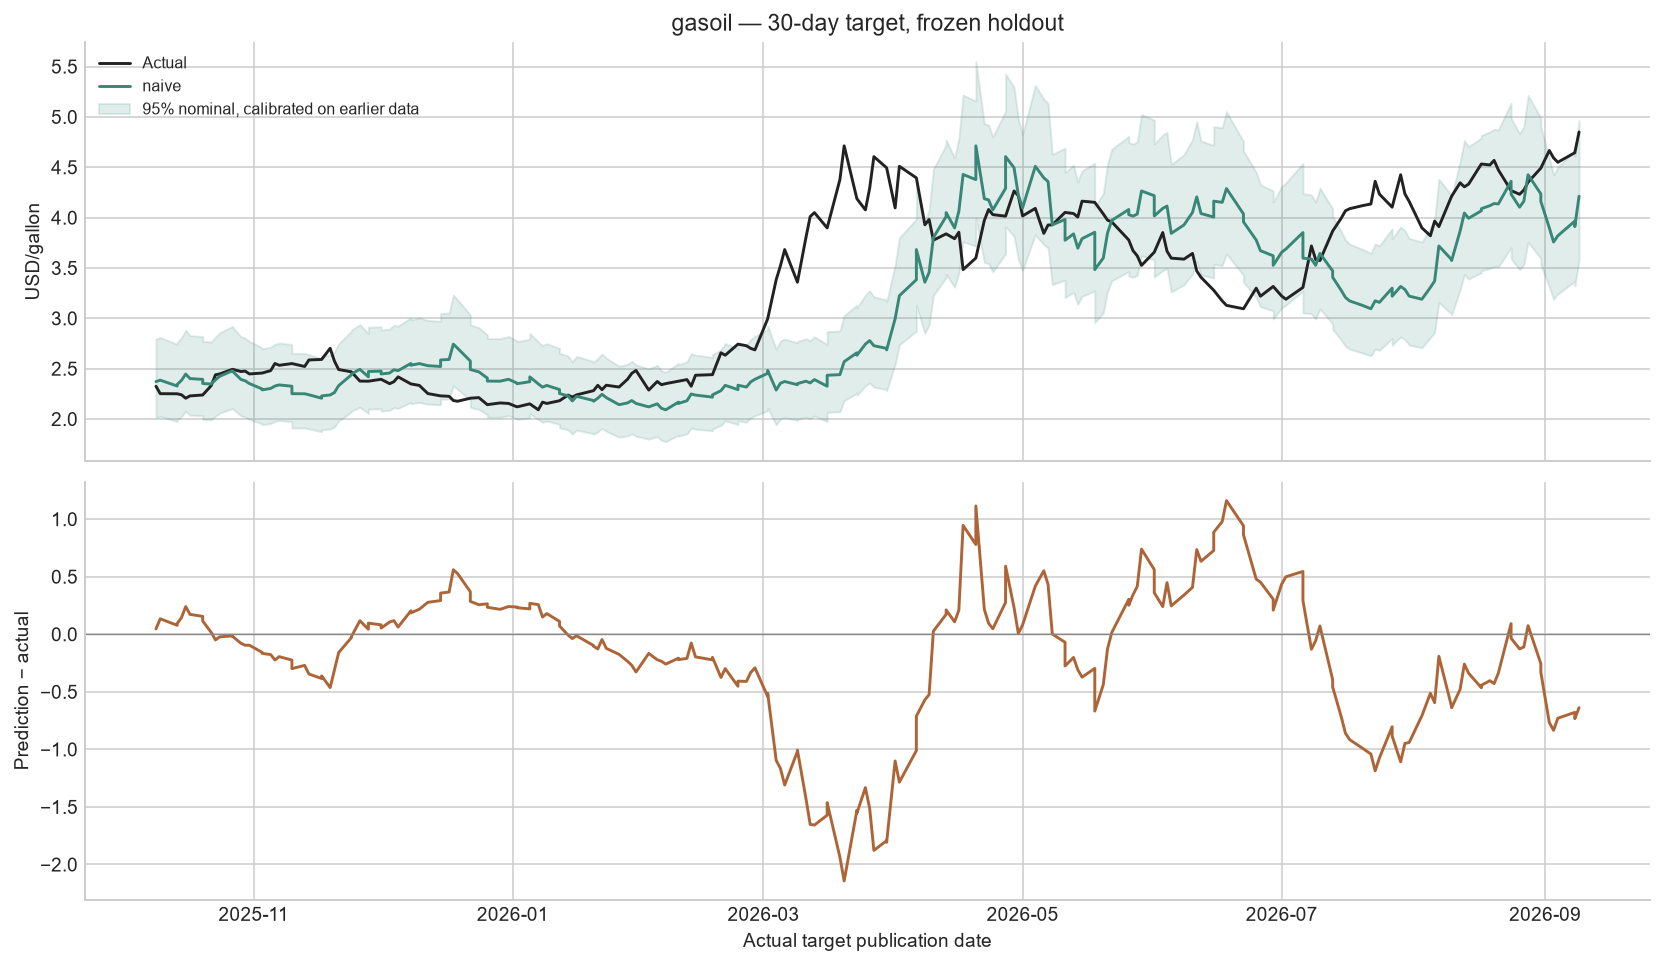

In [19]:
display(Image(filename=str(REPORTS / "holdout_brent_30.png")))
display(Image(filename=str(REPORTS / "holdout_gasoil_30.png")))

### Feature importance plot

Permutation importance measures how much calibration-set log-return MAE changes when a feature is shuffled. It explains the strongest machine-learning candidate at the 30-day horizon. Negative values mean shuffling happened to improve the score; correlated features can share or substitute signal, so importance is not causal and is not a feature-deletion rule.

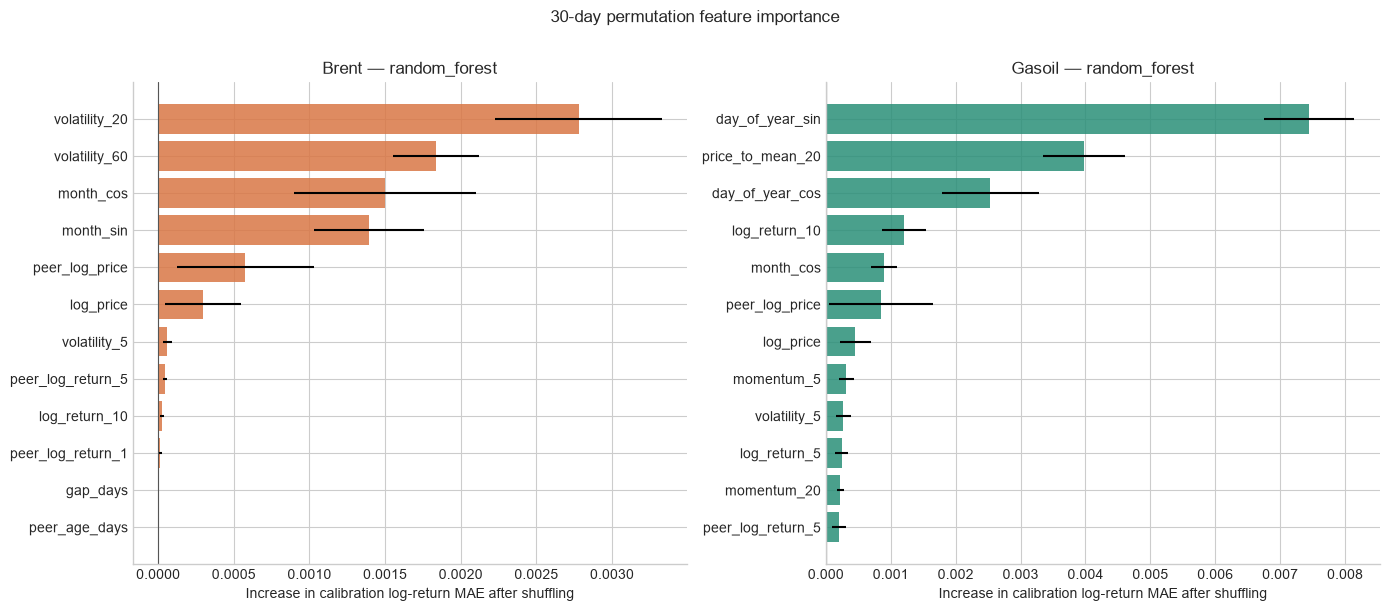

In [20]:
importance = pd.read_csv(REPORTS / "feature_importance.csv")
importance["product"] = importance["product"].astype(str).str.strip().str.lower()
importance["horizon_days"] = pd.to_numeric(importance["horizon_days"], errors="raise")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, product_name in zip(axes, ("brent", "gasoil")):
    product_importance = (
        importance.loc[
            importance["product"].eq(product_name) & importance["horizon_days"].eq(30)
        ]
        .sort_values("importance_mean")
        .tail(12)
    )
    if product_importance.empty:
        raise ValueError(f"No 30-day feature importance rows found for {product_name}")
    ax.barh(
        product_importance["feature"], product_importance["importance_mean"],
        xerr=product_importance["importance_std"], color=colors[product_name], alpha=0.85,
    )
    ax.axvline(0, color="#555", lw=0.8)
    model_name = product_importance["model"].iloc[0]
    ax.set(
        title=f"{product_name.title()} — {model_name}",
        xlabel="Increase in calibration log-return MAE after shuffling",
    )

fig.suptitle("30-day permutation feature importance", y=1.01)
plt.tight_layout()
plt.show()

## 10. Model Tuning

Hyperparameters are tuned on expanding, purged validation folds—not on the final holdout. The compact grid tests Ridge regularization strengths (`alpha = 1, 10, 100`) and boosting tree sizes (`max_leaf_nodes = 7, 15`). Other settings and the random seed remain fixed for reproducibility.

The table below ranks variants by mean validation MAE within each product and horizon. The production-selection rule still compares the best tuned candidate with persistence and requires a 2% improvement.

,product,horizon_days,model,mean_cv_mae,std_cv_mae,folds,rank_within_horizon
4,brent,1,ridge_100,1.352884,0.286351,3,1
9,brent,7,ridge_100,3.487235,1.385253,3,1
14,brent,30,ridge_100,8.402262,5.138358,3,1
19,brent,90,ridge_100,15.252112,15.513913,3,1
24,gasoil,1,ridge_100,0.062376,0.036716,3,1
29,gasoil,7,ridge_100,0.175560,0.125508,3,1
34,gasoil,30,ridge_100,0.475613,0.293813,3,1
39,gasoil,90,ridge_100,1.098993,0.545553,3,1


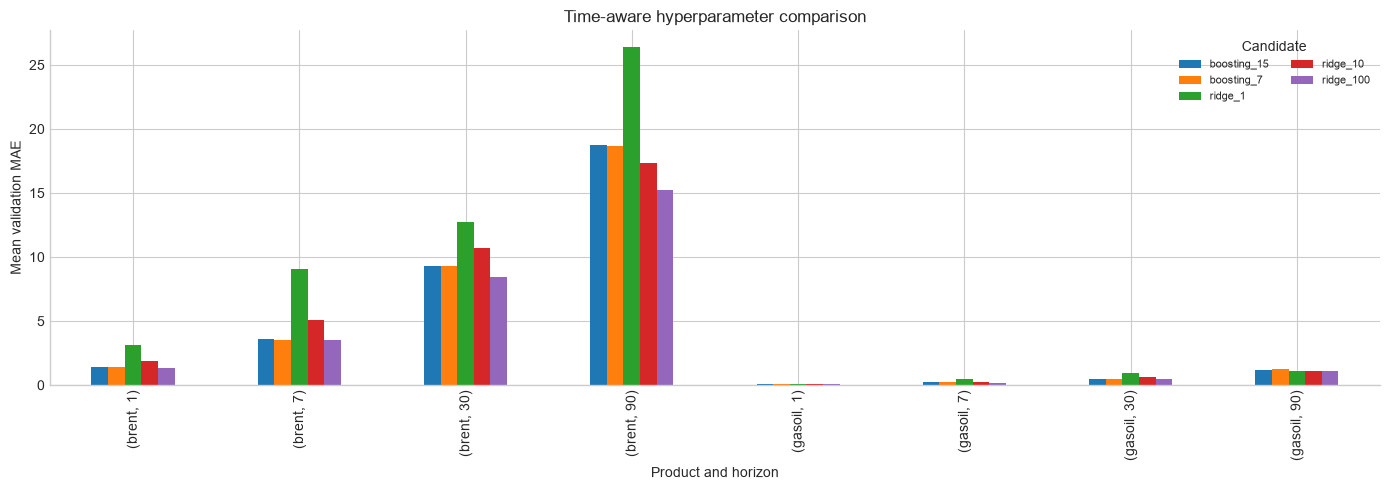

In [21]:
tuned = validation_metrics[
    validation_metrics.model.str.startswith(("ridge_", "boosting_"))
].copy()
tuning_summary = (
    tuned.groupby(["product", "horizon_days", "model"], as_index=False)
    .agg(mean_cv_mae=("mae", "mean"), std_cv_mae=("mae", "std"), folds=("fold", "nunique"))
)
tuning_summary["rank_within_horizon"] = (
    tuning_summary.groupby(["product", "horizon_days"])["mean_cv_mae"]
    .rank(method="dense")
    .astype(int)
)
best_tuned = tuning_summary[tuning_summary.rank_within_horizon == 1]
display(best_tuned.sort_values(["product", "horizon_days"]))

ax = tuning_summary.pivot_table(
    index=["product", "horizon_days"], columns="model", values="mean_cv_mae"
).plot.bar(figsize=(14, 5))
ax.set(title="Time-aware hyperparameter comparison", xlabel="Product and horizon", ylabel="Mean validation MAE")
ax.legend(title="Candidate", ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

## Conclusions and next actions

1. Use the validation-selected model for each product and horizon; do not change selection after viewing holdout results.
2. Treat persistence as a serious baseline. A complex model is useful only when its chronological validation gain is stable and meaningful.
3. Monitor data freshness, feature ranges, forecast error, and empirical interval coverage on new data.
4. Re-tune using new chronological observations rather than repeatedly optimizing against this frozen holdout.
5. Add release timestamps, revision vintages, transaction costs, freight, FX, and supplier quotes before using results for operational trading or purchasing decisions.

The full machine-readable audit is available in `reports/data_science/`, including model cards, predictions, split boundaries, feature importance, metrics, and environment fingerprints.

In [22]:
report_path = REPORTS / "report.md"
print(f"Detailed audit: {report_path.relative_to(ROOT)}")
print(f"Manifest: {(REPORTS / 'manifest.json').relative_to(ROOT)}")
display(Markdown("**Workflow complete.** All stages use the same validated snapshot and chronological evaluation design."))

Detailed audit: reports\data_science\report.md
Manifest: reports\data_science\manifest.json


**Workflow complete.** All stages use the same validated snapshot and chronological evaluation design.